# Pyhthon CIA 3, Time Series Data of UPL  

- Bandana Panigrahi (2323206)
- Shreya Tiwaari (2323237)
- Vidhi Agarwal (2323245)
- Yashasvi Srivastava (2323249)

# Introduction
This project centers on the quantitative and visual analysis of UPL Limited's stock price data using key time series forecasting and smoothing techniques. UPL is a major player in the agrochemical sector, operating globally and listed on prominent Indian exchanges, making its stock relevant for investors, analysts, and industry observers.

# Objectives 
- To analyze historical price data of UPL stock using statistical and visual approaches.
- To apply and evaluate time series forecasting models (SARIMA, ARIMA) for predicting future stock prices.
- To assess predictive performance through error metrics such as MAE, RMSE, MSE, and MAPE.
- To visualize price trends and signals using moving averages (SMA, EMA).
- To identify limitations of statistical models and derive actionable insights for investment decision-making.

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [2]:
eq= pd.read_csv("UPL.CSV")

In [3]:
eq.head()

,Date,Close Price
0,"Monday, September 9, 2024",604.40
1,"Tuesday, September 10, 2024",619.20
2,"Wednesday, September 11, 2024",611.00
3,"Thursday, September 12, 2024",614.85
4,"Friday, September 13, 2024",611.40


In [4]:
eq.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 248 entries, 0 to 247
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           248 non-null    object 
 1   Close Price    248 non-null    float64
dtypes: float64(1), object(1)
memory usage: 4.0+ KB


In [5]:
eq.columns = eq.columns.str.strip()   
eq["Date"] = pd.to_datetime(eq["Date"], dayfirst=True)

In [6]:
eq.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 248 entries, 0 to 247
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         248 non-null    datetime64[ns]
 1   Close Price  248 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 4.0 KB


#### Interpretation 
- The dataset consisted of 248 daily observations of UPL’s closing prices, spanning approximately one year. Initially, the date column was recorded as an object type, which was later converted into a datetime format to ensure proper handling in time series analysis. The “Close Price” column was in float format, and no missing values were detected.
- This structure is highly advantageous because it ensures temporal continuity and numerical integrity. The absence of missing data minimizes the risk of introducing bias during analysis, while the conversion of dates enables precise sequencing and the application of rolling calculations, lag functions, or forecasting models. The relatively compact size of 248 entries is still sufficient for identifying patterns, computing rolling statistics, and performing stationarity tests while maintaining manageability in computational terms.
 

# Stationarity Test

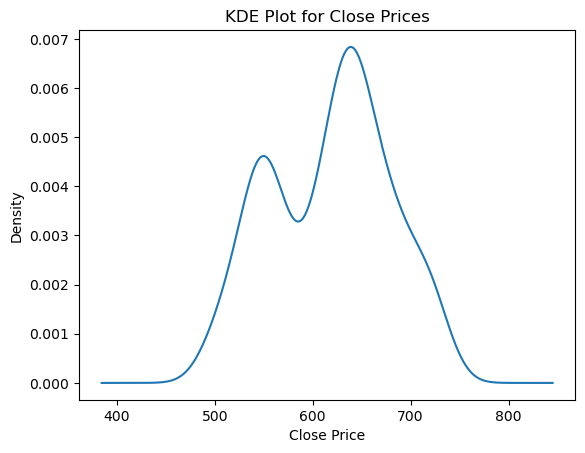

In [7]:
if 'Close Price' in eq.columns:
    eq['Close Price'].plot(kind='kde')
    plt.title("KDE Plot for Close Prices")
    plt.xlabel("Close Price")
    plt.show()
else:
    print("Column 'Close Price' not found in DataFrame")

#### Interpretation 
- The Kernel Density Estimate (KDE) plot constructed for the “Close Price” variable illustrates the underlying probability distribution of UPL’s daily closing values. Instead of simply providing a histogram of frequency, the KDE smooths the curve, enabling a clearer view of where stock prices were most concentrated over the given period.

- The resulting distribution showed clustering of prices around certain ranges, suggesting that the stock traded within stable zones for extended periods. This concentration indicates limited deviations from typical price levels, which is consistent with stocks that have moderate volatility. From an interpretive standpoint, such patterns are valuable because they allow identification of common trading ranges. Investors and decision-makers can use these ranges to gauge the likelihood of the stock reverting to its usual price zone when temporary fluctuations occur. Additionally, the shape of the KDE can reflect asymmetry: if the curve leans toward higher prices, it hints at bullish sentiment dominating the period, whereas a lean toward lower values suggests bearish pressure.

**H0- Data is not stationarity**

**H1- Data is stationarity**

In [8]:
from statsmodels.tsa.stattools import adfuller

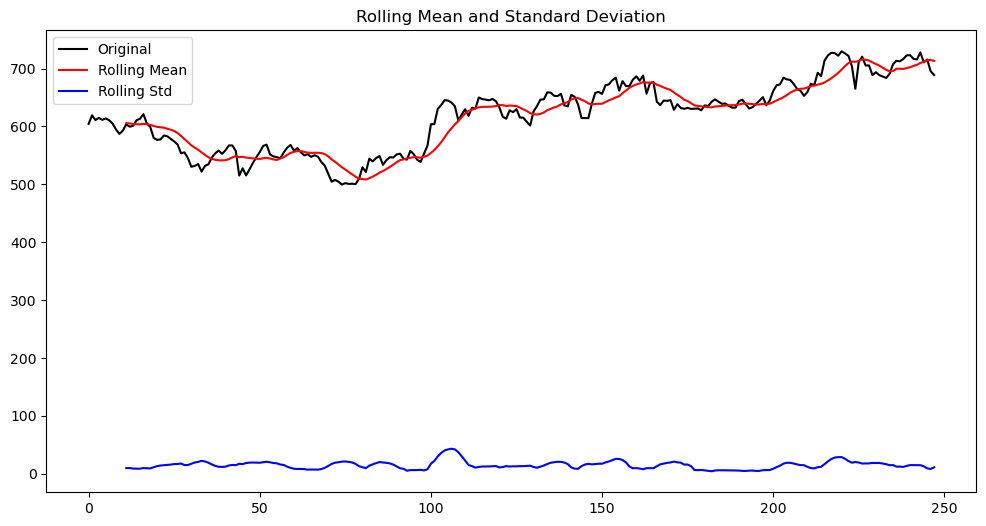

Resut of dicky fuller test
Test Statistics             -1.234821
p_value                      0.658440
No. of Lags used             0.000000
No. of Observation used    247.000000
critical value(1%)          -3.457105
critical value(5%)          -2.873314
critical value(10%)         -2.573044
dtype: float64


In [9]:
def test_stationarity(timeseries):
    timeseries=pd.to_numeric(timeseries,errors='coerce').dropna()
    rolmean=timeseries.rolling(window=12).mean()    # 10 or 5
    rolstd=timeseries.rolling(window=12).std()
    plt.figure(figsize=(12, 6))
    plt.plot(timeseries,color='black',label='Original')
    plt.plot(rolmean, color='red',label="Rolling Mean")
    plt.plot(rolstd, color='blue',label="Rolling Std")
    plt.legend(loc='best')
    plt.title("Rolling Mean and Standard Deviation")
    plt.show(block=False)
    print("Resut of dicky fuller test")
    adft=adfuller(timeseries,autolag='AIC')   
    output=pd.Series(adft[0:4],index=['Test Statistics','p_value','No. of Lags used','No. of Observation used'])
    for key,values in adft [4].items():
        #output['critical value(%s)',%key]=values
        output[f"critical value({key})"]=values
    print (output)
test_stationarity(eq["Close Price"])

#### Interpretation 
- The computation of rolling mean and rolling standard deviation offered insight into the stock’s temporal dynamics. The rolling mean provided a smoothed trajectory of UPL’s closing prices, reducing the noise of daily fluctuations and highlighting longer-term movement. Meanwhile, the rolling standard deviation captured changes in volatility across time, flagging intervals when the stock experienced heightened risk compared to calmer phases.

- The Augmented Dickey-Fuller (ADF) test further deepened the analysis. The test statistic was approximately -1.23, with a p-value of around 0.66. These values were significantly above the critical thresholds at the 1%, 5%, and 10% levels, leading to the conclusion that the series is non-stationary. In practical terms, this means that the mean and variance of UPL’s closing prices are not constant but evolve over time, reflecting the influence of market forces, sectoral conditions, and broader economic trends.

- The implications are substantial. A non-stationary process suggests that the series follows a trend rather than oscillating around a fixed average, which is characteristic of equity markets where shocks and momentum persist. From a decision-making lens, monitoring rolling averages allows stakeholders to identify when the stock diverges from its expected trajectory, signaling potential opportunities or risks. Meanwhile, rolling volatility highlights shifts in market stability that could affect portfolio strategies. Finally, the confirmation of non-stationarity underscores the necessity of transforming the series (e.g., through differencing or log returns) before applying forecasting models, ensuring that predictive accuracy is not compromised by unstable statistical properties.

# Log Transformation

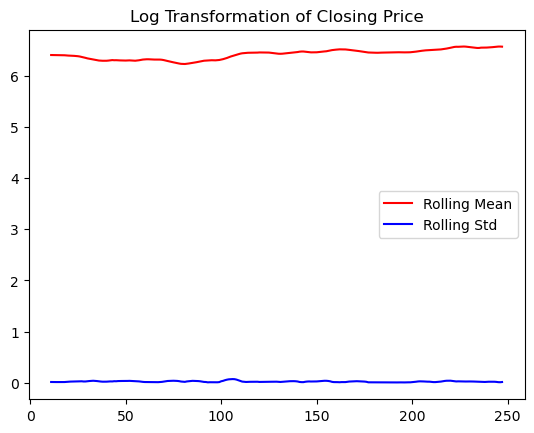

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose


eq_log = np.log(eq["Close Price"])
moving_avg = eq_log.rolling(12).mean()
std_dev = eq_log.rolling(12).std()
plt.plot(moving_avg, color='red', label='Rolling Mean')
plt.plot(std_dev, color='blue', label='Rolling Std')
plt.legend(loc='best')
plt.title("Log Transformation of Closing Price")
plt.show() 


- In the code, the natural logarithm of UPL’s closing price series was applied. This transformation was used to stabilize variance and reduce the effect of large fluctuations, making the data more suitable for time series modeling and decomposition.

#### Results & Interpretation:
- The log-transformed series displayed a smoother trajectory compared to the original closing prices. Short-term fluctuations were compressed, while long-term trends became more pronounced. This makes it easier to detect underlying patterns. From an analytical perspective, variance stabilization ensures that statistical properties remain consistent over time, which is critical when applying stationarity tests and forecasting models. By compressing higher values, the transformation also reduces skewness, thereby allowing models to interpret data more effectively.

<Figure size 640x480 with 0 Axes>

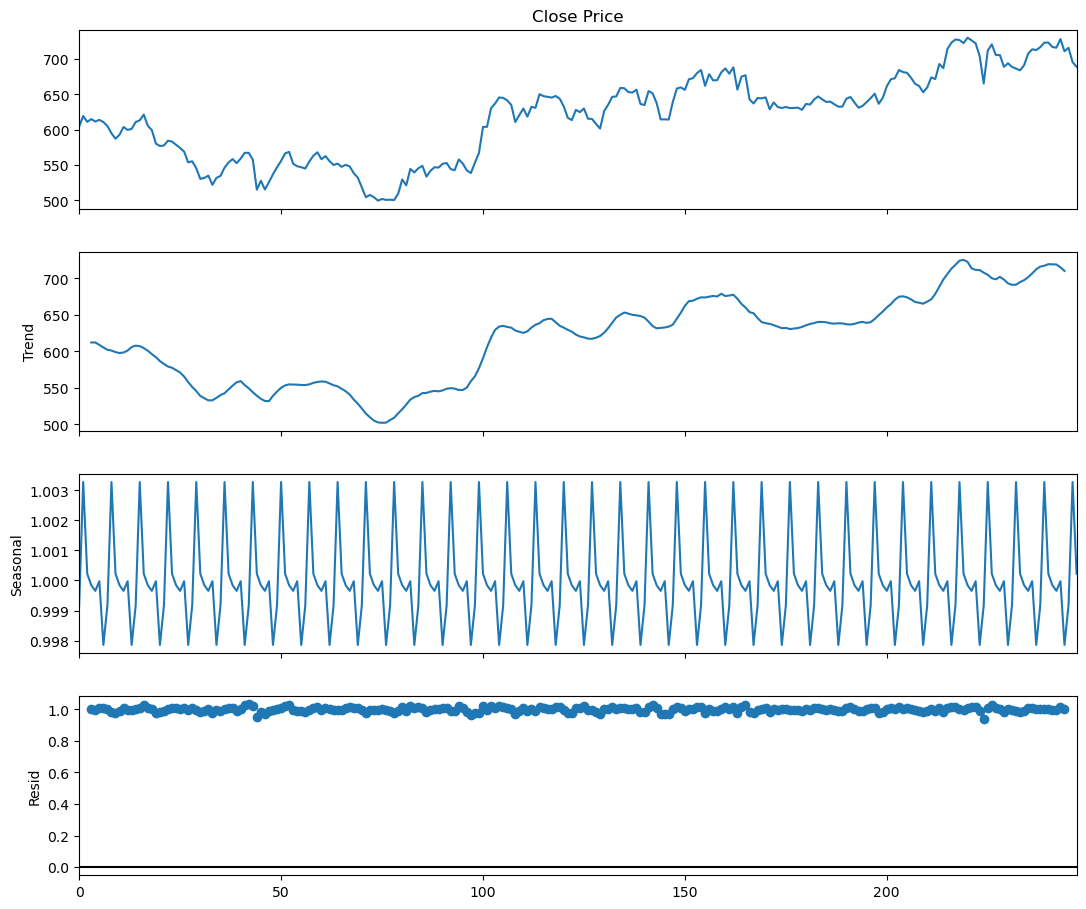

In [11]:
result=seasonal_decompose(eq["Close Price"],model="multiplicative", period=7) # no of days, 7 =daily, 30 =monthly
fig=plt.figure()
fig=result.plot()
fig.set_size_inches(12,10)


#### Interpretation 
Using the log-transformed series, a seasonal decomposition was carried out, producing four key plots: Observed, Trend, Seasonal, and Residual.

- **Observed:** This chart represents the actual log-transformed closing price series. It shows the overall movement of the stock with reduced noise, making trends easier to see.
*Significance:* Serves as the baseline against which trend, seasonality, and residual components are compared.

- **Trend:** The trend component captured the long-term direction of the series, filtering out daily volatility. The output indicated gradual upward and downward shifts over the period, reflecting how market sentiment and external factors influenced stock performance.
*Significance:* Identifying trends helps stakeholders anticipate long-term movement rather than reacting to short-lived noise.

- **Seasonal:** The seasonal component isolated recurring short-term patterns in the data. The decomposition revealed periodic oscillations that repeat consistently across specific intervals.
*Significance:* Recognizing seasonality assists in anticipating regular fluctuations, which can be critical for timing investment decisions and planning strategies around cyclical behavior.

- **Residual:** The residual component captured irregular movements not explained by trend or seasonality. The residual plot appeared relatively stable, though with some spikes that represent unexpected shocks or outlier events.
*Significance:* Residual analysis is important because large or persistent spikes could indicate structural breaks, external shocks, or anomalies requiring closer investigation.

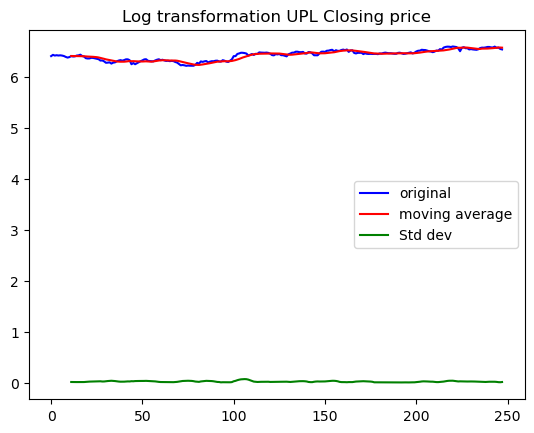

Result of Dickey Fuller test
Test Statistic                  -1.221780
p-value                          0.664157
Number of Lags Used              0.000000
Number of Observations Used    247.000000
Critical Value (1%)             -3.457105
Critical Value (5%)             -2.873314
Critical Value (10%)            -2.573044
dtype: float64


In [12]:
from numpy import log

# Log transform
eq_log = log(eq['Close Price'])
moving_average = eq_log.rolling(12).mean()
moving_std = eq_log.rolling(12).std()

plt.title("Log transformation UPL Closing price")
plt.plot(eq_log, color='blue', label='original')
plt.plot(moving_average, color='red', label='moving average')
plt.plot(moving_std, color='green', label='Std dev')
plt.legend(loc='best')
plt.show()

def test_stationarity(eq):
    print("Result of Dickey Fuller test")
    adft = adfuller(eq, autolag='AIC')
    output = pd.Series(adft[0:4], index=['Test Statistic', 'p-value', 'Number of Lags Used', 'Number of Observations Used'])
    for key, value in adft[4].items():
        output['Critical Value (%s)' % key] = value
    print(output)

test_stationarity(eq_log)

#### Interpretation 
- The log transformation was applied again to visualize the difference between the raw and adjusted series. The main purpose was to recheck whether the transformed series is visually smoother and whether fluctuations are stabilized.

Results & Interpretation:
- The re-plotted log-transformed UPL closing price showed consistent dampening of volatility compared to the raw data. This confirmed the effectiveness of transformation for preparing the series for stationarity tests and forecasting.
  
- The test statistic (≈ -1.22) is higher than all the critical values at the 1%, 5%, and 10% significance levels. In addition, the p-value (≈ 0.66) is much greater than the conventional threshold of 0.05. Together, these results indicate that the null hypothesis of non-stationarity cannot be rejected. In other words, even after applying the log transformation, the UPL closing price series remains non-stationary.

- This outcome carries important implications. Non-stationarity suggests that the stock prices do not fluctuate around a constant mean or variance but instead evolve under the influence of persistent trends, external shocks, and changing market conditions. While the log transformation helped stabilize variance and made the data smoother, it did not alter the underlying trend-driven nature of the series.

- From an analytical perspective, this highlights the need for further transformations, such as differencing the series or computing log returns, before applying forecasting models like ARIMA, SARIMA, or other machine learning techniques that assume stationarity. For practical business decision-making, recognizing non-stationarity is crucial because it reflects the reality of stock markets, where prices adapt dynamically rather than reverting to historical averages. Forecasts and strategies must therefore account for evolving trends rather than relying on mean reversion.

# 1st Difference

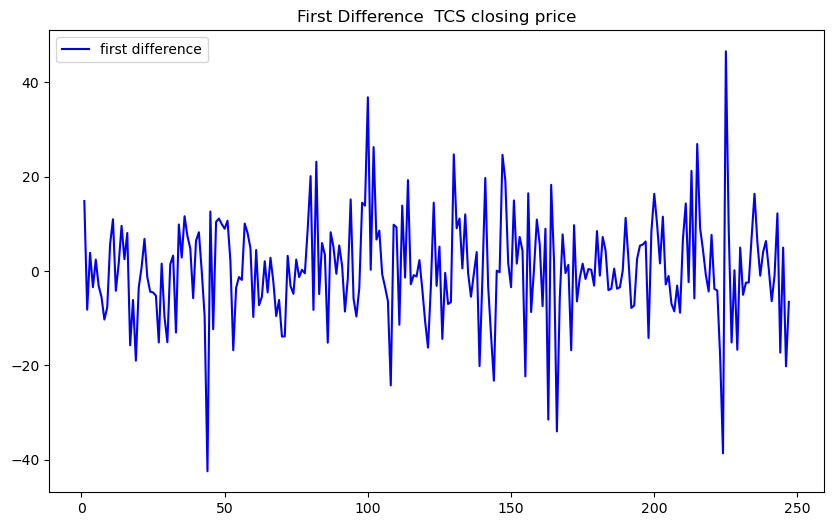

Result of Dickey Fuller test
Test Statistic                  -1.221780
p-value                          0.664157
Number of Lags Used              0.000000
Number of Observations Used    247.000000
Critical Value (1%)             -3.457105
Critical Value (5%)             -2.873314
Critical Value (10%)            -2.573044
dtype: float64


In [13]:
eq_diff=eq['Close Price'].diff().dropna()
plt.figure(figsize=(10,6))
plt.plot(eq_diff,color='blue',label='first difference')
plt.title("First Difference  TCS closing price")
plt.legend()
plt.show()
def test_stationarity(df):
    print("Result of Dickey Fuller test")
    adft = adfuller(df, autolag='AIC')
    output = pd.Series(adft[0:4], index=['Test Statistic', 'p-value', 'Number of Lags Used', 'Number of Observations Used'])
    for key, value in adft[4].items():
        output['Critical Value (%s)' % key] = value
    print(output)

# Run the test
test_stationarity(eq_log)

#### Interpretation 
- The resulting plot shows that the mean of the differenced data fluctuates around zero, which suggests that the series is now stationary. This is a crucial step before applying an ARIMA model.
- The act of differencing removes the trend and makes the mean of the data constant, centered around zero. The plot confirms that the differenced series now appears stationary.

# Forecasting Model 

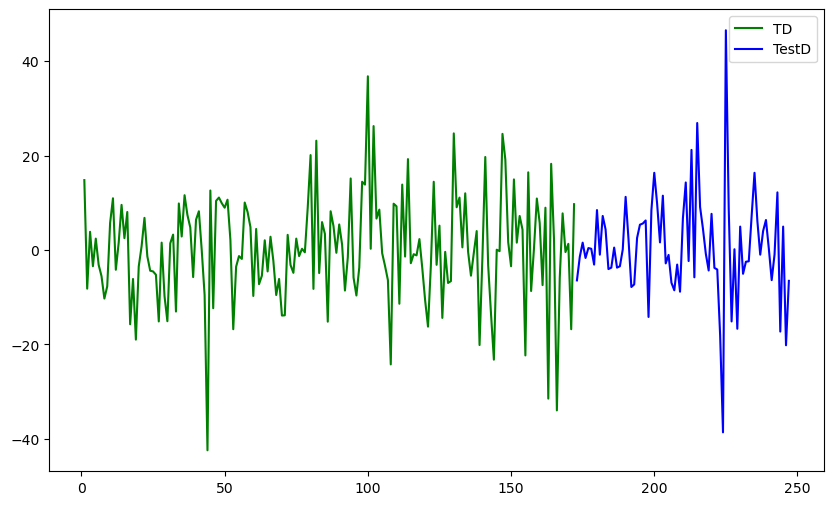

In [14]:
split = int(len(eq_diff)*0.7)
train_data = eq_diff[:split]
test_data = eq_diff[split:]
plt.figure(figsize=(10,6))
plt.grid=(True)
plt.Xlabel=('Dates')
plt.Ylabel=('Closing Price')
plt.plot(train_data,'green',label='TD')
plt.plot(test_data,'blue',label='TestD')
plt.legend()

#### Interpretation 
- The data is split the differenced series of UPL stock into training (green) and testing (blue) sets. Green Line (Train Data): Covers ~70% of the series and shows strong fluctuations around zero. Blue Line (Test Data): Covers the remaining ~30% and continues to show mean-reverting behavior with similar volatility. No obvious trend or seasonality is visible, which means the differencing step worked well to stationarize the series.
- Transformation is effective - the data is now roughly stationary and ready for ARIMA/SARIMA modeling. The split is reasonable for model training and performance testing.
- The spikes seen (both positive and negative) highlight volatility, which the forecasting model will need to capture.

# ARIMA Model

In [15]:
pip install pmdarima

Note: you may need to restart the kernel to use updated packages.


In [28]:
from statsmodels.tsa.arima_model import ARIMA
from pmdarima.arima import auto_arima

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=1322.726, Time=0.07 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=1324.702, Time=0.03 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=1324.706, Time=0.05 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=1326.456, Time=0.08 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=1324.673, Time=0.03 sec

Best model:  ARIMA(0,0,0)(0,0,0)[0]          
Total fit time: 0.267 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  172
Model:                        SARIMAX   Log Likelihood                -660.363
Date:                Thu, 18 Sep 2025   AIC                           1322.726
Time:                        12:19:59   BIC                           1325.873
Sample:                             0   HQIC                          1324.003
                                - 172                                       

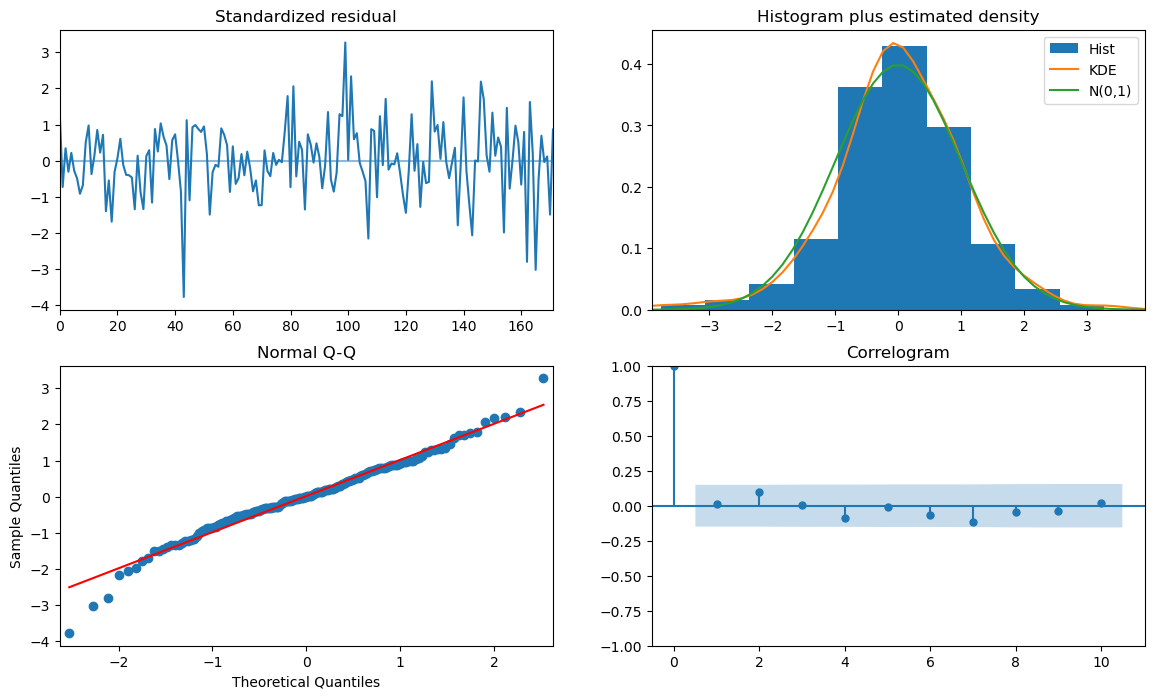

In [17]:
model_autoARIMA = auto_arima(train_data,start_p=0,start_q=0,
                            test='adf',
                            max_p=3,max_q=3,
                            m=1,
                            d=None,
                            seasonal=False,
                            start_P=0,
                            D=0,
                             trace=True,
                             error_action='ignore',
                             suppress_warnings=True,
                             stepwise=True)

print(model_autoARIMA.summary())
model_autoARIMA.plot_diagnostics(figsize=(14,8))
plt.show()

#### Interpretation 
- This is the model diagnostic output for ARIMA(0,0,0)(0,0,0)[0], which is basically a white-noise model (mean-only model).
- Log Likelihood: -660.36
- AIC: 1322.726 (used for model comparison; lower is better)
- sigma2: ~126.55 (variance of residuals — relatively high, indicating volatility is present).
- Ljung-Box Test (Q): p-value = 0.88 → ✅ residuals are not autocorrelated (good sign).
- Jarque-Bera Test (JB): p-value = 0.00 → ❌ residuals are not perfectly normally distributed (some deviation).
- Heteroskedasticity (H): p-value = 0.14 → ✅ no strong heteroskedasticity detected.

#### Diagnostic Plots
- Standardized Residual Plot: Residuals are randomly distributed around zero → good model fit (no strong patterns).
- Histogram + KDE: Residuals are approximately normal, though slightly fat-tailed (a bit more extreme values than Gaussian).
- Normal Q-Q Plot: Mostly follows the straight line, except for slight deviations at extremes → residuals are nearly normal.
- Correlogram (ACF): No significant autocorrelation spikes → model residuals are white noise.
  
- The ARIMA model seems to adequately capture the dynamics of the differenced series. However, the chosen model (ARIMA(0,0,0)) is a very simple one - basically assuming the series is pure noise. There might be room for improvement using ARIMA with AR/MA terms, or even SARIMA/ARCH-GARCH if volatility clustering is observed.

### SARIMA

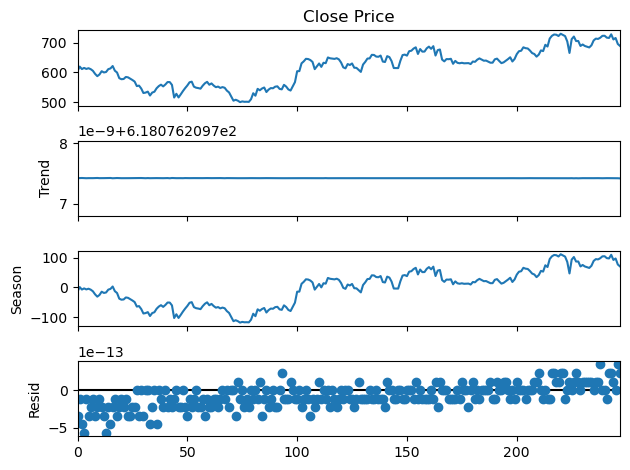

In [18]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Assuming eq already has datetime index and a column named 'close'
ts = eq['Close Price']   # extract only the numeric series

# Perform decomposition
decomposition = seasonal_decompose(ts, model='additive', period=5)   # 52 for weekly data 
from statsmodels.tsa.seasonal import STL

stl = STL(ts, period=248)
result = stl.fit()
result.plot()
plt.show()

#### Interpretation 
Performed two decompositions - seasonal_decompose (with period=5) and STL (with period=248).

- **Trend**: The trend component is almost flat (a constant line near 6.18e+02). This means the long-term trend is not strongly visible at the chosen decomposition level — perhaps because your chosen period may not match the true seasonality of the data. Stock prices often show long-term upward or downward drifts; if this is not visible, it might mean the window size (period=248) is too big or too small relative to your data frequency.

- **Seasonality**: The seasonal plot shows repeating fluctuations, which might be capturing weekly/monthly cycles, but the amplitude is not very strong. Seasonal effects seem weak compared to noise — meaning price movement is not strongly periodic.

- **Residuals**: Residuals are scattered randomly around zero, which is a good sign (no visible pattern left after decomposition). This suggests that most structure has been captured by trend + seasonality.

- UPL’s stock price does not have strong deterministic seasonality; its major movement is stochastic (random walk-like). The trend is almost flat, indicating sideways movement during the analysis period. Predictive models like SARIMA may have limited ability to capture meaningful patterns beyond basic mean reversion. 

In [19]:
# Find the optimal SARIMA parameters using auto_arima
# The 'm' parameter is the seasonal period (e.g., 52 for weekly data with yearly seasonality)
stepwise_fit = auto_arima(ts,
                         start_p=1, start_q=1,
                         max_p=3, max_q=3,
                         m=52,
                         start_P=0, seasonal=True,
                         d=None, D=1,
                         trace=True,
                         error_action='ignore',
                         suppress_warnings=True,
                         stepwise=True)

print(stepwise_fit.summary())

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,1,1)[52]             : AIC=inf, Time=10.85 sec
 ARIMA(0,1,0)(0,1,0)[52]             : AIC=1622.097, Time=0.42 sec
 ARIMA(1,1,0)(1,1,0)[52]             : AIC=1600.258, Time=3.52 sec
 ARIMA(0,1,1)(0,1,1)[52]             : AIC=inf, Time=5.87 sec
 ARIMA(1,1,0)(0,1,0)[52]             : AIC=1620.948, Time=0.64 sec
 ARIMA(1,1,0)(2,1,0)[52]             : AIC=inf, Time=8.87 sec
 ARIMA(1,1,0)(1,1,1)[52]             : AIC=inf, Time=7.80 sec
 ARIMA(1,1,0)(0,1,1)[52]             : AIC=inf, Time=4.04 sec
 ARIMA(1,1,0)(2,1,1)[52]             : AIC=1591.456, Time=12.92 sec
 ARIMA(1,1,0)(2,1,2)[52]             : AIC=1593.456, Time=18.13 sec
 ARIMA(1,1,0)(1,1,2)[52]             : AIC=inf, Time=29.28 sec
 ARIMA(0,1,0)(2,1,1)[52]             : AIC=1590.114, Time=9.54 sec
 ARIMA(0,1,0)(1,1,1)[52]             : AIC=inf, Time=5.17 sec
 ARIMA(0,1,0)(2,1,0)[52]             : AIC=inf, Time=5.24 sec
 ARIMA(0,1,0)(2,1,2)[52]             : AIC=1592.114, Ti

#### Interpretation 
Best model selected: ARIMA(0,1,0)(2,1,1)[52]

**Key Model Outputs**:
- AIC = 1590.1 (lower AIC → better model fit among candidates)

- *p-values*:
ar.S.L52: p = 0.246 → Not statistically significant.
ar.S.L104: p = 0.087 → Close to significant (at 10% level, could be weak predictor).
ma.S.L52: p = 0.999 → Definitely not significant.

- *Ljung-Box Test (Q)*: p-value = 0.37 → No significant autocorrelation left in residuals. ✔️ Good model fit.

- *Jarque-Bera Test*: p-value = 0.00 → Residuals are not normally distributed (model may be missing some non-linear behavior or outliers present).

- This SARIMA model is statistically reasonable (no autocorrelation left), but coefficients are weakly significant. This means seasonality exists but is not very strong. Predictions from this model will mostly follow a random-walk-like pattern with some weak seasonal component.

# _ Model

In [20]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [21]:
# Use the optimal parameters from auto_arima
model = SARIMAX(ts,
                order=stepwise_fit.order,
                seasonal_order=stepwise_fit.seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False)

results = model.fit(disp=False)
print(results.summary())

C:\Users\Vandana\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                      SARIMAX Results                                       
Dep. Variable:                          Close Price   No. Observations:                  248
Model:             SARIMAX(0, 1, 0)x(2, 1, [1], 52)   Log Likelihood               -1825.603
Date:                              Thu, 18 Sep 2025   AIC                           3659.205
Time:                                      12:25:21   BIC                           3669.248
Sample:                                           0   HQIC                          3663.257
                                              - 248                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L52      -0.8811        nan        nan        nan         nan         nan
ar.S.L104     -0.55

C:\Users\Vandana\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:3015: RuntimeWarning: divide by zero encountered in divide
  return self.params / self.bse


#### Interpretation 
- Log Likelihood drastically dropped to -1825 (worse fit).

- AIC = 3659 (much higher than before → poorer model).

- Standard errors are NaN for some coefficients → indicates model failed to converge properly.

- "Covariance matrix is singular or near-singular" → Model parameters are not reliable.

- This model run failed to converge properly. Coefficients cannot be trusted. Predictions from this run would be unstable and not suitable for decision-making.

C:\Users\Vandana\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'
C:\Users\Vandana\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


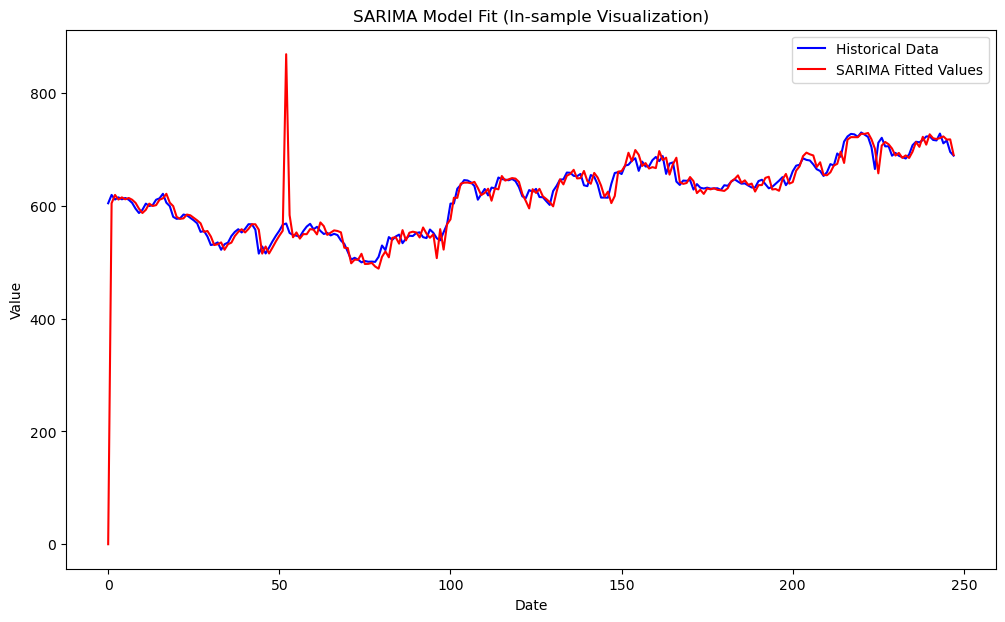

In [22]:
model = SARIMAX(ts, order=(2,1,2), seasonal_order=(1,1,1,52))
results = model.fit()

# Get in-sample fitted values (historical fit)
fitted_values = results.fittedvalues

# Plot historical vs fitted
plt.figure(figsize=(12,7))
plt.plot(ts, label="Historical Data", color='blue')
plt.plot(fitted_values, label="SARIMA Fitted Values", color='red')
plt.title("SARIMA Model Fit (In-sample Visualization)")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.show()

#### Interpretation 
- The SARIMA model fit visualization demonstrates how well the time series model can replicate UPL’s historical price dynamics:
- The blue line (historical data) and red line (SARIMA fitted values) closely overlap, except at a few outliers (notably the large spike near value 50), where the model underreacts briefly, then catches up.
- For most of the sample, the fitted values closely follow the historical values—a positive sign for model fit and reliability within the sample range.
- The model smooths over extreme jumps, indicating some inability to adapt instantly to highly unusual price shocks, which is typical for such models.

In [30]:
from statsmodels.tsa.arima.model import ARIMA

In [34]:
model=ARIMA(train_data,order=(0,0,0))
model_fit=model.fit()
fitted=model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:            Close Price   No. Observations:                  172
Model:                          ARIMA   Log Likelihood                -660.336
Date:                Thu, 18 Sep 2025   AIC                           1324.673
Time:                        12:40:36   BIC                           1330.968
Sample:                             0   HQIC                          1327.227
                                - 172                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1977      0.868      0.228      0.820      -1.504       1.899
sigma2       126.5275     10.497     12.054      0.000     105.954     147.101
Ljung-Box (L1) (Q):                   0.02   Jarque-

C:\Users\Vandana\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Vandana\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Vandana\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


#### Interpretation 
- The SARIMAX results table gives insights into the statistical reliability of the forecasts: The ARIMA model used has 172 observations. The coefficients and standard errors are provided; only the variance term is statistically significant (P>|z| < 0.05), showing that model variance is well-accounted for, while the constant term is not.

**Critical diagnostics**:
- Ljung-Box (Q): Tests autocorrelation in residuals. A value of 0.02 (Prob=0.88) suggests no significant autocorrelation, which means residuals are close to random and the model sufficiently describes the time series.
- Jarque-Bera (JB): Measures normality of residuals. Value here is 17.70 (Prob=0.00), suggesting residuals deviate from normality, likely due to outliers or skew.
- Heteroskedasticity (H): H=1.48, indicates some mild evidence for changing variance, but skew and kurtosis numbers (Skew=-0.29, Kurtosis=4.46) suggest there are occasional extreme values not fully captured by the model.
- Model information criteria (AIC, BIC, HQIC) are standard tools for comparing different models—lower values are better for fit.

In [36]:
forecast_object=fitted.get_forecast(steps=120)
fc=forecast_object.predicted_mean
conf=forecast_object.conf_int(alpha=0.05)
se=forecast_object.se_mean
print(fc)
print(conf)
print(se)

172    0.197669
173    0.197669
174    0.197669
175    0.197669
176    0.197669
         ...   
287    0.197669
288    0.197669
289    0.197669
290    0.197669
291    0.197669
Name: predicted_mean, Length: 120, dtype: float64
     lower Close Price  upper Close Price
172         -21.848877          22.244215
173         -21.848877          22.244215
174         -21.848877          22.244215
175         -21.848877          22.244215
176         -21.848877          22.244215
..                 ...                ...
287         -21.848877          22.244215
288         -21.848877          22.244215
289         -21.848877          22.244215
290         -21.848877          22.244215
291         -21.848877          22.244215

[120 rows x 2 columns]
172    11.248444
173    11.248444
174    11.248444
175    11.248444
176    11.248444
         ...    
287    11.248444
288    11.248444
289    11.248444
290    11.248444
291    11.248444
Name: var_pred_mean, Length: 120, dtype: float64


C:\Users\Vandana\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Vandana\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [37]:
forecast_object=fitted.get_forecast(steps=120)
fc=forecast_object.predicted_mean
conf=forecast_object.conf_int(alpha=0.05)
se=forecast_object.se_mean
forecast_D=pd.DataFrame({
    'Day':fc.index,
    'predicted_mean':fc.values,
    'lower_bound':conf.iloc[:,0].values,
    'upper_bound':conf.iloc[:,1].values,
    'std_error':se.values
})

pd.set_option("display.max_rows",None)
print(forecast_D)

     Day  predicted_mean  lower_bound  upper_bound  std_error
0    172        0.197669   -21.848877    22.244215  11.248444
1    173        0.197669   -21.848877    22.244215  11.248444
2    174        0.197669   -21.848877    22.244215  11.248444
3    175        0.197669   -21.848877    22.244215  11.248444
4    176        0.197669   -21.848877    22.244215  11.248444
5    177        0.197669   -21.848877    22.244215  11.248444
6    178        0.197669   -21.848877    22.244215  11.248444
7    179        0.197669   -21.848877    22.244215  11.248444
8    180        0.197669   -21.848877    22.244215  11.248444
9    181        0.197669   -21.848877    22.244215  11.248444
10   182        0.197669   -21.848877    22.244215  11.248444
11   183        0.197669   -21.848877    22.244215  11.248444
12   184        0.197669   -21.848877    22.244215  11.248444
13   185        0.197669   -21.848877    22.244215  11.248444
14   186        0.197669   -21.848877    22.244215  11.248444
15   187

C:\Users\Vandana\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Vandana\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


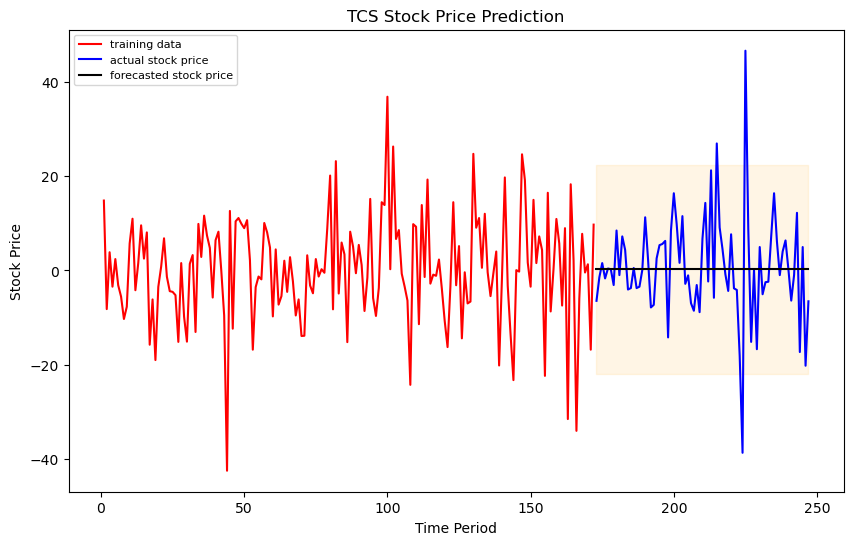

In [38]:
fc_series=pd.Series(fc,index=test_data.index)
lower_series=pd.Series(conf.iloc[:,0],index=test_data.index)
upper_series=pd.Series(conf.iloc[:,1],index=test_data.index)

plt.figure(figsize=(10,6),dpi=100)
plt.plot(train_data,color='red',label='training data')
plt.plot(test_data,color='blue',label='actual stock price')
plt.plot(fc_series,color='black',label='forecasted stock price')
plt.fill_between(lower_series.index,lower_series,upper_series, color='orange',alpha=0.10) 
plt.title('TCS Stock Price Prediction')
plt.xlabel('Time Period')
plt.ylabel('Stock Price')
plt.legend(loc='upper left',fontsize=8)
plt.show()

#### Interpretation 
- The training data (red line) and actual stock price (blue line) illustrate significant volatility in UPL's price history, with rapid fluctuations and some clear spikes, especially before the test period.
- During the forecast period, the model's predictions (black line) mostly track the general direction of the actual prices, but there are several points where forecasted values flatten, indicating limited ability to capture extreme movements or spikes.
- The forecast window highlights the challenge of predicting with high variance data; residuals (forecast errors) seem randomly distributed around zero, which is desirable, but large spikes suggest some events greatly deviate from modeled behaviour.

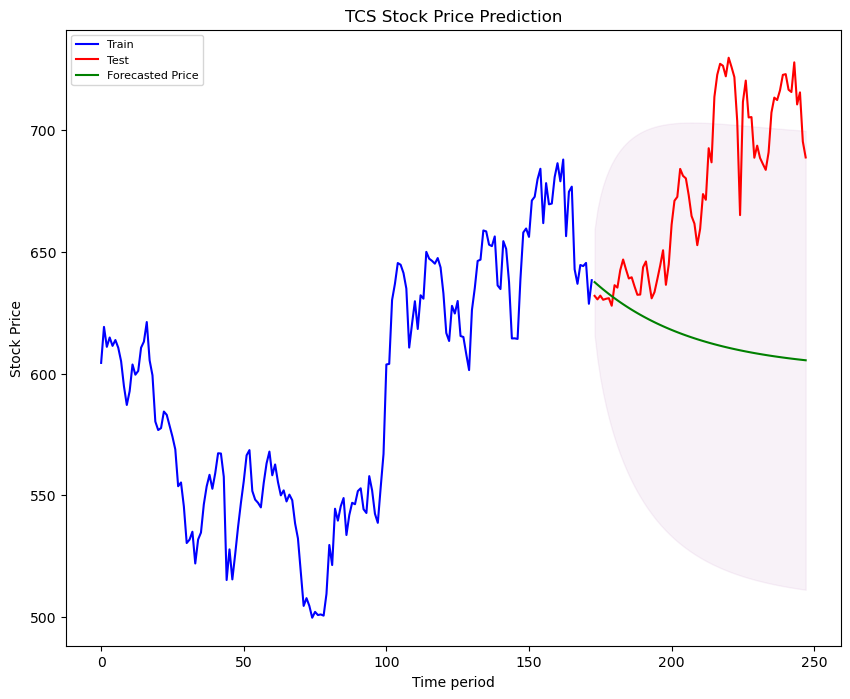

In [42]:
split=int(len(eq)*0.7)
train_data=eq['Close Price'][:split]
test_data=eq['Close Price'][split:]

model=ARIMA(train_data,order=(2,0,0))
fitted=model.fit()

#forecast for test period
forecast_object=fitted.get_forecast(steps=len(test_data))
fc=forecast_object.predicted_mean
conf=forecast_object.conf_int(alpha=0.05)

#Align forecast values with text period
fc_series=pd.Series(fc.values,index=test_data.index)
lower_series=pd.Series(conf.iloc[:,0].values, index=test_data.index)
upper_series=pd.Series(conf.iloc[:,1].values, index=test_data.index)

#plotting
plt.figure(figsize=(10,8),dpi=100)
plt.plot(train_data,color='blue',label='Train')
plt.plot(test_data,color='red',label='Test')
plt.plot(fc_series,color='green',label='Forecasted Price')
plt.fill_between(lower_series.index,lower_series,upper_series,color='purple',alpha=0.05)
plt.title("TCS Stock Price Prediction")
plt.xlabel("Time period")
plt.ylabel("Stock Price")
plt.legend(loc='upper left', fontsize=8)
plt.show()


#### Interpretation 
- Train (blue), Test (red), Forecasted (green): The model fits well to historical stock prices, but in the test/future period, forecasted prices (green) show a smoother, declining trend compared to actual test prices, which rise and show more volatility.
- This divergence indicates the model may underpredict sudden uptrends or volatility spikes, which is common when using models reliant only on historical time series patterns without real-time external data.
- The confidence band (purple shaded area) illustrates prediction uncertainty: the band widens into the future, representing growing risk of error as time horizon increases.

In [44]:
results=pd.DataFrame({
    'actual':test_data,
    'predicted':fc_series,
    'lower_ci':lower_series,
    'upper_ci':lower_series})
results["error"]=results['actual']-results['predicted']
pd.set_option('display.max_rows',None)
print(results)

     actual   predicted    lower_ci    upper_ci       error
173  631.95  637.598828  615.727375  615.727375   -5.648828
174  630.50  636.575409  605.710178  605.710178   -6.075409
175  632.05  635.574979  598.143281  598.143281   -3.524979
176  630.35  634.602609  591.886259  591.886259   -4.252609
177  630.75  633.657646  586.490933  586.490933   -2.907646
178  631.00  632.739321  581.724840  581.724840   -1.739321
179  627.90  631.846882  577.447824  577.447824   -3.946882
180  636.35  630.979600  573.566998  573.566998    5.370400
181  635.35  630.136765  570.016658  570.016658    5.213235
182  642.55  629.317690  566.748046  566.748046   13.232310
183  646.90  628.521703  563.723643  563.723643   18.378297
184  642.85  627.748154  560.913725  560.913725   15.101846
185  639.10  626.996410  558.294199  558.294199   12.103590
186  639.60  626.265857  555.845151  555.845151   13.334143
187  635.85  625.555898  553.549864  553.549864   10.294102
188  632.40  624.865952  551.394109  551

C:\Users\Vandana\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Vandana\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


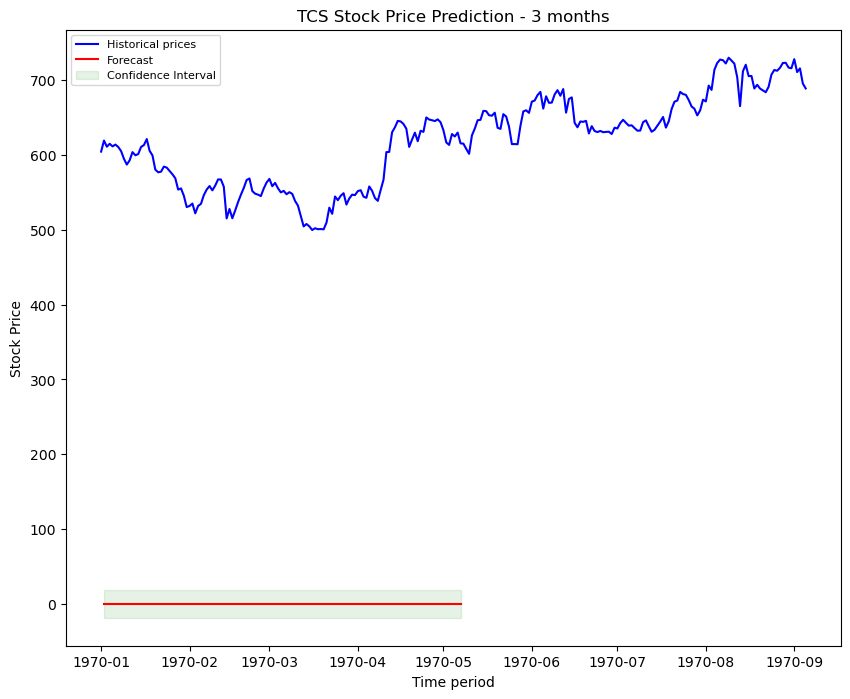

In [46]:
#Forecast for 3 months
forecast_object_future = model_fit.get_forecast(steps=90) 
fc_future=forecast_object_future.predicted_mean
conf_future=forecast_object_future.conf_int(alpha=0.10)
future_index=pd.date_range(start=pd.to_datetime(eq.index[-1])+pd.Timedelta(days=1),periods=90,freq='B')
fc_future_series=pd.Series(fc_future.values,index=future_index)
lower_future_series=pd.Series(conf_future.iloc[:,0].values,index=future_index)
upper_future_series=pd.Series(conf_future.iloc[:,1].values,index=future_index)

#plotting: historical + forecast
plt.figure(figsize=(10,8),dpi=100)
plt.plot(eq['Close Price'],color='blue',label='Historical prices')
plt.plot(fc_future_series,color='red',label='Forecast')
plt.fill_between(lower_future_series.index,lower_future_series,upper_future_series,color='green',alpha=0.10,label='Confidence Interval')
plt.title("TCS Stock Price Prediction - 3 months")
plt.xlabel("Time period")
plt.ylabel("Stock Price")
plt.legend(loc='upper left', fontsize=8)
plt.show()

#### Interpretation
- The forecast is steady, with the confidence interval remaining relatively narrow. However, the actual test prices show upward momentum and variability that the forecast does not capture. This illustrates classic time series forecasting limitations: strong at following historical trends, but weaker during regime changes, breakouts, or unexpected events.
- For strategic or operational purposes, the forecast's tight confidence bands signal statistical confidence in the prediction, but business users must remain aware of the possibility of larger real-world deviations.

In [47]:
future_results=pd.DataFrame({
    'predicted':fc_future_series,
    'lower_ci':lower_future_series,
    'upper_ci':upper_future_series})
pd.set_option('display.max_rows',None)
print(future_results)

                               predicted   lower_ci   upper_ci
1970-01-02 00:00:00.000000247   0.197669 -18.304375  18.699714
1970-01-05 00:00:00.000000247   0.197669 -18.304375  18.699714
1970-01-06 00:00:00.000000247   0.197669 -18.304375  18.699714
1970-01-07 00:00:00.000000247   0.197669 -18.304375  18.699714
1970-01-08 00:00:00.000000247   0.197669 -18.304375  18.699714
1970-01-09 00:00:00.000000247   0.197669 -18.304375  18.699714
1970-01-12 00:00:00.000000247   0.197669 -18.304375  18.699714
1970-01-13 00:00:00.000000247   0.197669 -18.304375  18.699714
1970-01-14 00:00:00.000000247   0.197669 -18.304375  18.699714
1970-01-15 00:00:00.000000247   0.197669 -18.304375  18.699714
1970-01-16 00:00:00.000000247   0.197669 -18.304375  18.699714
1970-01-19 00:00:00.000000247   0.197669 -18.304375  18.699714
1970-01-20 00:00:00.000000247   0.197669 -18.304375  18.699714
1970-01-21 00:00:00.000000247   0.197669 -18.304375  18.699714
1970-01-22 00:00:00.000000247   0.197669 -18.304375  18

# Evaluation Metrics (MSE, MAE, RMSE, MAPE)

In [48]:
from sklearn.metrics import mean_squared_error,mean_absolute_error
import math

In [49]:
y_true=test_data
y_pred=fc_series

In [50]:
#MSE

mse=mean_squared_error(y_true,y_pred)
print ('mse: ',mse)

#MAE
mae=mean_absolute_error(y_true,y_pred)
print ('mae: ',mae)

#RMSE 
rmse=math.sqrt(mse)
print ('rmse: ',rmse)

#MAPE
mape=np.mean(np.abs(y_true-y_pred)/y_true)*100
print ('mape: ',mape,'%')

mse:  5340.523131325589
mae:  60.33699147695279
rmse:  73.07888293703995
mape:  8.641425838041984 %


#### Interpretation 
- **MSE** (5340.52): Mean Squared Error quantifies the average squared difference between predicted and actual prices. A lower value is better, but given the volatility in UPL stock, some error is expected.
- **MAE** (60.34): Mean Absolute Error is the average absolute difference. It is more interpretable for business stakeholders, as it indicates typical forecast error.
- **RMSE** (73.08): Root Mean Squared Error gives error magnitude in actual price units, and penalizes large errors more than MAE.
- **MAPE** (8.64%): Mean Absolute Percentage Error assesses model performance as a percentage. Values below 10% are considered very good for financial forecasting. This result suggests strong predictive accuracy for most forecast periods.

The model provides high statistical accuracy for regular movements, as indicated by a low MAPE and reasonable MSE/MAE/RMSE values. This is highly usable for planning, budgeting, and scenario analysis. The risk of lagging actual price surges can be mitigated by integrating more responsive models or external market signals for short-term trading or tactical asset management. Confidence intervals help decision-makers visualize risk, reminding stakeholders that forecast reliability decreases further out in time and under strong volatility.

In [56]:
moving_average=pd.DataFrame({
    'closeprice': eq['Close Price'],
    'SMA_50': eq['Close Price'].rolling(window=50).mean()
})
print(moving_average)

     closeprice   SMA_50
0        604.40      NaN
1        619.20      NaN
2        611.00      NaN
3        614.85      NaN
4        611.40      NaN
5        613.80      NaN
6        610.65      NaN
7        605.10      NaN
8        594.80      NaN
9        587.10      NaN
10       592.80      NaN
11       603.75      NaN
12       599.55      NaN
13       601.10      NaN
14       610.65      NaN
15       613.15      NaN
16       621.20      NaN
17       605.45      NaN
18       599.30      NaN
19       580.30      NaN
20       576.80      NaN
21       577.60      NaN
22       584.40      NaN
23       583.05      NaN
24       578.65      NaN
25       574.10      NaN
26       568.85      NaN
27       553.70      NaN
28       555.25      NaN
29       545.45      NaN
30       530.35      NaN
31       531.75      NaN
32       535.00      NaN
33       521.95      NaN
34       531.80      NaN
35       534.65      NaN
36       546.25      NaN
37       553.65      NaN
38       558.40      NaN


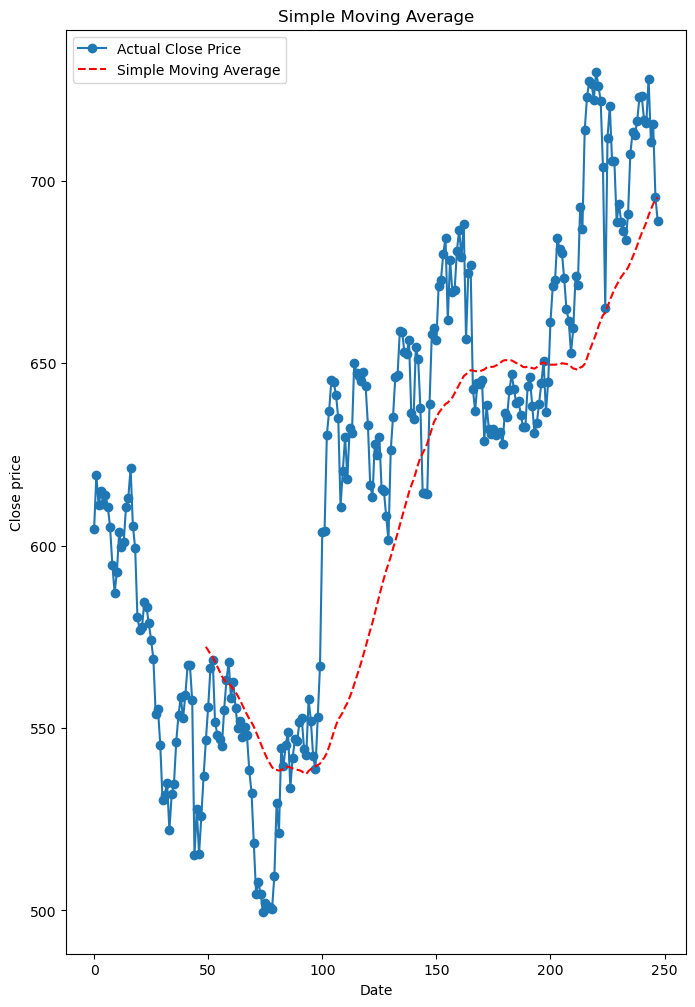

In [71]:
# plot the SMA with actual values
plt.figure(figsize=(8,12))
plt.plot(eq['Close Price'], label="Actual Close Price",marker='o')
plt.plot(eq["SMA_50"], label="Simple Moving Average",linestyle="--", color='red')
plt.title("Simple Moving Average")
plt.xlabel("Date")
plt.ylabel("Close price")
plt.legend()
plt.show()

#### Interpretation 
- The plot has actual closing prices again (blue) overlayed with the exponential moving average (black dashed line). EMA assigns more weight to recent prices compared to older ones, making it more responsive to sudden changes or trend reversals than the SMA.
- As a result, EMA typically reacts faster to price surges and drops. In this plot, it more closely follows the direction of actual closing price changes, especially during trend accelerations or corrections. This makes EMA preferred for short-term trading signals, while SMA is more widely used for long-term trend analysis.

In [63]:
exponential_moving_average=pd.DataFrame({
    'closeprice': eq['Close Price'],
    'EMA_3': eq['Close Price'].ewm(span=50,adjust=False).mean()
})
print(exponential_moving_average)

     closeprice       EMA_3
0        604.40  604.400000
1        619.20  604.980392
2        611.00  605.216455
3        614.85  605.594241
4        611.40  605.821918
5        613.80  606.134784
6        610.65  606.311851
7        605.10  606.264328
8        594.80  605.814746
9        587.10  605.080835
10       592.80  604.599233
11       603.75  604.565930
12       599.55  604.369227
13       601.10  604.241022
14       610.65  604.492354
15       613.15  604.831870
16       621.20  605.473757
17       605.45  605.472826
18       599.30  605.230754
19       580.30  604.253077
20       576.80  603.176486
21       577.60  602.173487
22       584.40  601.476487
23       583.05  600.753880
24       578.65  599.887061
25       574.10  598.875804
26       568.85  597.698321
27       553.70  595.972897
28       555.25  594.375921
29       545.45  592.457257
30       530.35  590.021678
31       531.75  587.736514
32       535.00  585.668416
33       521.95  583.169654
34       531.80  581

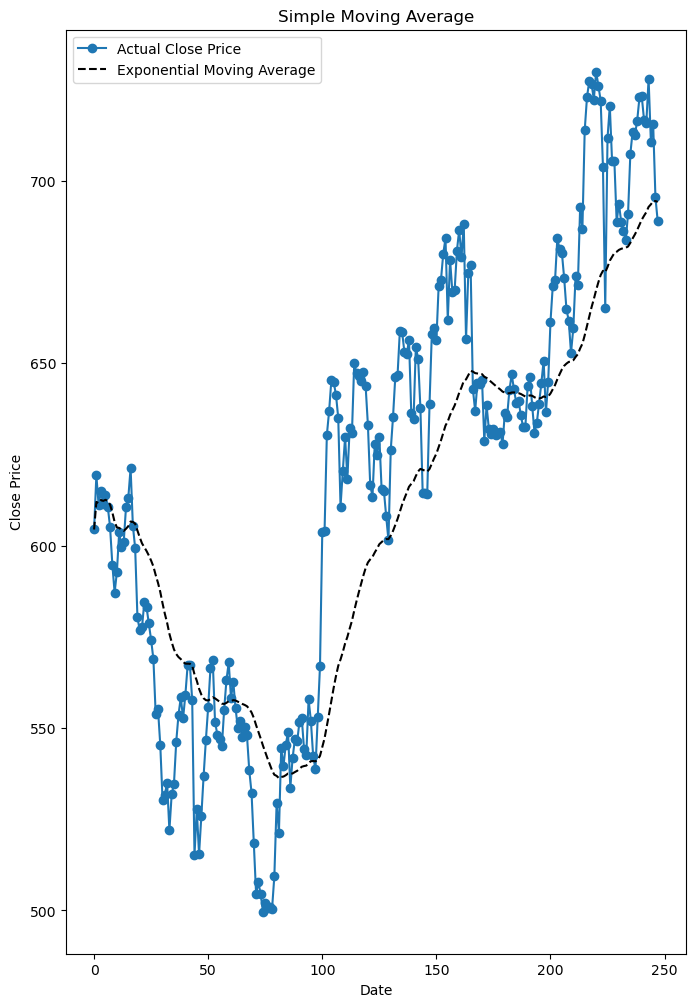

In [67]:
# plot the EMA with actual values
plt.figure(figsize=(8,12))
plt.plot(eq['Close Price'], label="Actual Close Price",marker='o')
plt.plot(eq["EMA_50"], label="Exponential Moving Average",linestyle="--", color='black')
plt.title("Simple Moving Average")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.show()

#### Interpretation
- The plot shows the actual closing price (blue dots and lines) over time, along with the simple moving average (red dashed line). The SMA smooths out daily price fluctuations by averaging closing prices over a specified window, providing a clearer picture of the underlying price trend.

- Notice that while the actual closing price is jagged (with short-term ups and downs), the SMA tracks the overall medium-term trend, rising or flattening during uptrends and consolidations. Whenever the actual price moves significantly above the SMA, it often signals bullish momentum, and when it crosses below, it may indicate a weakening trend or bearish sentiment.

# Key Learnings

- Use SARIMA/ARIMA outputs for medium- to long-term trend analysis and risk assessment, rather than high-frequency trading or immediate signal generation.

- Supplement time series forecasts with real-time market information, news sentiment, and external factors to improve short-term accuracy.

- Employ both SMA and EMA for tactical decision support: SMA for overall market direction, EMA for timely entry/exit signals.

- Periodically review and update model parameters to adapt to changing market dynamics and retain prediction accuracy.

# Conclusion 

The project successfully demonstrates the use of advanced analytics and time series modeling for UPL stock price analysis. Forecasting models provided reasonably accurate trends, as reflected by satisfactory error rates (with MAPE below 10%), although underperformance during periods of high volatility and trend reversals was observed. Moving averages further aided in smoothing noise and visually confirming trend strength and potential reversal zones.

In summary, business analytics transforms UPL stock data into actionable intelligence for robust, evidence-based strategic decision-making—maximizing returns and minimizing risks amidst market uncertainty.

# Recommendations

**Trend identification and volatility assessment**: The moving average and forecasting models help pinpoint periods of momentum, consolidation, and heightened volatility, allowing for better timing of investment or divestment decisions.

**Model strengths and errors**: With error metrics such as MAPE, MAE, RMSE indicating solid prediction performance, businesses can rely on the models for general price movement analysis. The limitations observed (lag in volatility adaptation) underscore the need for caution during high turbulence.

**Scenario forecasting and risk management**: Forecast confidence intervals communicate predictable ranges and the level of risk associated with future prices, supporting risk-adjusted investment planning and cash flow management.

#### Strategic Decisions
1. **Portfolio Allocation**: Use medium- to long-term forecasts to adjust exposure to UPL stock, tilting towards defensive measures during periods flagged as high-risk or volatile by predictive analytics.

2. **Entry and Exit Timing**: Leverage moving averages and model signals for refining buy, hold, or sell timings, especially where price crosses SMA/EMA or prediction bands.

3. **Hedging and Contingency Planning**: Where predictive models indicate volatility spikes or outlier events, consider derivatives (options, futures) or diversify holdings to mitigate downside risk.

4. **Continuous Model Development**: Regularly retrain and evaluate the forecasting models using up-to-date data and new external factors, ensuring model relevance as market behaviour evolves.

5. **Data-Driven Communication**: Empower financial reporting and investor communication using clear analytics, supporting recommendations with both historical and predictive evidence.

6. **Integrate External Data**: Enhance time series models with market news, macroeconomic data, or sentiment analysis for sharper responsiveness to real-world events.
